In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
path = 'Dataset_2025_IceClass/'
file_path = 'S1A_EW_GRDM_1SDH_20250218T031612_20250218T031712_057945_07267C_A597_fix_IceClass.tif' 
files_all = os.listdir(path)

In [4]:
files = files_all[:10]
files = list(map(lambda x: path + x, files))

In [7]:
path = 'test_output2/'
file = 'polygon_pipeline_demo_stack_cropped.tif'
output_file = 'BINARY_MASK_' + file

input_path = os.path.join(path, file)
out_path = os.path.join(path, output_file)

if not os.path.exists(input_path):
    print(f"Файл не найден: {input_path}")
else:
    with rasterio.open(input_path) as src:
        if src.count < 3:
            raise ValueError(f"Ожидается минимум 3 канала (RGB), получено: {src.count}")
        rgb = src.read((1, 2, 3))
        class0 = (
            (rgb[0] == 0) & (rgb[1] == 0) & (rgb[2] == 0)
        )
        binary_mask = (class0.astype(np.uint8) * 255)

        out_meta = src.meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "dtype": rasterio.uint8,
            "count": 1,
            "nodata": 0,
        })

        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(binary_mask, 1)
            dst.update_tags(mask_kind="iceclass_class0_rgb_1_1_1")

    n = int(class0.sum())
    print(f"Пикселей класса 0 [1,1,1]: {n}")
    print(f"Маска сохранена: {out_path}")

Пикселей класса 0 [1,1,1]: 258866395
Маска сохранена: test_output2/BINARY_MASK_polygon_pipeline_demo_stack_cropped.tif


In [8]:
file = 'test_output3/polygon_pipeline_demo_class0_mask.tif'

with rasterio.open(file) as src:
    print(src.count)
    data = src.read(1)
    print(np.unique(data))

1
[0]


In [6]:
import rasterio
import numpy as np
import os

path = 'test_output2/'
file = 'polygon_pipeline_demo_class0_mask.tif'
output_file = 'BINARY_MASK_' + file

# Проверяем, существует ли файл
input_path = os.path.join(path, file)
if not os.path.exists(input_path):
    print(f"Файл не найден: {input_path}")
else:
    with rasterio.open(input_path) as src:
        data = src.read(1)
        print(np.unique(data))
        # 1. Читаем данные первого канала
        
        
        # 2. Создаем маску: все, что НЕ 0 (т.е. классы 1-7), превращаем в 255
        # Все, что 0, оставляем 0
        binary_mask = np.where(data > 0, 255, 0).astype(rasterio.uint8)
        
        # 3. Копируем метаданные из оригинала (ОБЯЗАТЕЛЬНО)
        out_meta = src.meta.copy()
        
        # Обновляем метаданные для нового файла (тип данных теперь uint8)
        out_meta.update({
            "driver": "GTiff",
            "dtype": rasterio.uint8,
            "count": 1
        })

        # 4. Записываем новый файл с метаданными
        with rasterio.open(output_file, 'w', **out_meta) as dst:
            dst.write(binary_mask, 1)

    print(f"Готово! Маска сохранена в файл: {output_file}")

[0]
Готово! Маска сохранена в файл: BINARY_MASK_polygon_pipeline_demo_class0_mask.tif


In [114]:
import rasterio
import numpy as np
from PIL import Image
import os

def create_ice_mask(input_tif, output_png):
    """
    Создает бинарную маску:
    0 (нет класса) -> Черный (0)
    1-7 (лед/вода) -> Белый (255)
    """
    if not os.path.exists(input_tif):
        print(f"Файл {input_tif} не найден!")
        return

    with rasterio.open(input_tif) as src:
        # Читаем данные (1-й канал)
        data = src.read(1)
        
        # Создаем пустую матрицу такого же размера
        mask = np.zeros(data.shape, dtype=np.uint8)
        
        # Все, что НЕ 0, делаем Белым (255)
        # Классы 1, 2, 3, 4, 5, 6, 7 попадут сюда
        mask[data > 0] = 255
        
        # Класс 0 останется Черным (0) по умолчанию
        
        # Сохраняем как PNG, чтобы сразу увидеть результат
        img = Image.fromarray(mask)
        img.save(output_png)
        
        # Считаем статистику для контроля
        total_pixels = data.size
        data_pixels = np.count_nonzero(mask)
        print(f"Обработан: {os.path.basename(input_tif)}")
        print(f"  - Всего пикселей: {total_pixels}")
        print(f"  - Пикселей с данными (1-7): {data_pixels} ({data_pixels/total_pixels*100:.1f}%)")
        print(f"  - Сохранено в: {output_png}")

# --- ЗАПУСК ---
# Можешь запустить на любом склеенном файле (который мы делали раньше)

input_file = path + file_path 
output_mask = "MASK_07325C.png"

create_ice_mask(input_file, output_mask)

Обработан: S1A_EW_GRDM_1SDH_20250310T021122_20250310T021223_058236_07325C_C593.SAFE_IceClass.tif
  - Всего пикселей: 14359034
  - Пикселей с данными (1-7): 7999800 (55.7%)
  - Сохранено в: MASK_07325C.png


Начинаю merge...


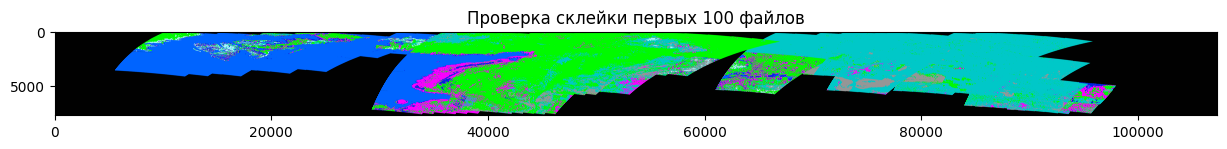

In [85]:
import rasterio
from rasterio.merge import merge
import matplotlib.pyplot as plt

files = files_all
files = list(map(lambda x: path + x, files))

# 1. Открываем файлы (возьмем первые 100 для пробы)
srcs = [rasterio.open(f) for f in files]

print("Начинаю merge...")
# 2. Склеиваем. nodata=1 скажет мерджу игнорировать фон [1,1,1]
mosaic, out_trans = merge(srcs, nodata=1)

# 3. Закрываем файлы
for s in srcs: s.close()

# 4. Визуализация
plt.figure(figsize=(15, 10))
# merge возвращает (Channels, H, W)
plt.imshow(np.moveaxis(mosaic, 0, -1))
plt.title("Проверка склейки первых 100 файлов")
plt.show()

In [108]:
import os
import rasterio
import pandas as pd
from datetime import datetime, timedelta

def scan_vizard_data(folder_path):
    """
    Сканирует папку и создает базу данных снимков.
    """
    data = []
    print(f"Индексация файлов в {folder_path}...")

    if not os.path.exists(folder_path):
        print(f"Ошибка: Путь {folder_path} не найден!")
        return pd.DataFrame()

    for filename in os.listdir(folder_path):
        if not filename.endswith(".tif"):
            continue
            
        parts = filename.split('_')
        # S1A(0)_EW(1)_GRDM(2)_1SDH(3)_START(4)_STOP(5)_ORBIT(6)_DATATAKE(7)_ID(8)...
        if len(parts) < 8:
            continue
            
        dt_id = parts[7]
        start_time_str = parts[4] # 20250423T024113
        
        try:
            # Парсим время
            dt_obj = datetime.strptime(start_time_str, "%Y%m%dT%H%M%S")
            
            # Открываем файл для получения географии
            path = os.path.join(folder_path, filename)
            with rasterio.open(path) as src:
                # Получаем центр снимка по долготе и широте
                b = src.bounds
                lon = (b.left + b.right) / 2
                lat = (b.top + b.bottom) / 2
            
            data.append({
                'data_take_id': dt_id,
                'filename': filename,
                'time': dt_obj,
                'lon': lon,
                'lat': lat
            })
        except Exception as e:
            print(f"Ошибка парсинга {filename}: {e}")

    df = pd.DataFrame(data)
    print(f"Готово. Проиндексировано {len(df)} файлов.")
    return df

def get_neighbors(target_id, df, hours_delta=48):
    """
    Возвращает ID соседей слева (West) и справа (East).
    """
    if target_id not in df['data_take_id'].values:
        return None, None, "ID не найден"

    # Данные целевого снимка
    target = df[df['data_take_id'] == target_id].iloc[0]
    
    # Фильтруем: берем только те, что были сняты в пределах +/- hours_delta
    # И на похожей широте (+/- 10 градусов), чтобы не брать другой конец Арктики
    time_mask = (df['time'] >= target['time'] - timedelta(hours=hours_delta)) & \
                (df['time'] <= target['time'] + timedelta(hours=hours_delta)) & \
                (abs(df['lat'] - target['lat']) < 10) & \
                (df['data_take_id'] != target_id)
    
    potential = df[time_mask].copy()
    
    if potential.empty:
        return None, None, "Соседи во временном окне не найдены"

    # Считаем разницу по долготе
    potential['lon_diff'] = potential['lon'] - target['lon']
    
    # Сосед слева (Запад) - отрицательная разница, самая близкая к 0
    left_side = potential[potential['lon_diff'] < 0]
    left_id = left_side.sort_values('lon_diff', ascending=False).iloc[0]['data_take_id'] if not left_side.empty else None
    
    # Сосед справа (Восток) - положительная разница, самая маленькая
    right_side = potential[potential['lon_diff'] > 0]
    right_id = right_side.sort_values('lon_diff', ascending=True).iloc[0]['data_take_id'] if not right_side.empty else None
    
    return left_id, right_id, "OK"

# --- ПРИМЕР ИСПОЛЬЗОВАНИЯ ---

path = 'vizard_iceclass/Dataset_2025_IceClass/'
df_ice = scan_vizard_data(path)

my_id = "074C49"
left, right, status = get_neighbors(my_id, df_ice)

print(f"\nДля ID: {my_id}")
print(f"Сосед слева (West): {left}")
print(f"Сосед справа (East): {right}")
print(f"Статус: {status}")

Индексация файлов в vizard_iceclass/Dataset_2025_IceClass/...
Готово. Проиндексировано 410 файлов.

Для ID: 074C49
Сосед слева (West): 074BAA
Сосед справа (East): 074BAA
Статус: OK


In [111]:
import os
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import Affine

def smart_merge_ice_frames(take_ids, source_folder, output_path):
    """
    Склеивает фреймы, корректно накладывая их друг на друга через общую проекцию.
    """
    files_to_merge = []
    all_files = os.listdir(source_folder)
    
    # 1. Собираем полные пути к файлам
    for tid in take_ids:
        if not tid: continue
        for fname in all_files:
            if fname.endswith(".tif") and f"_{tid}_" in fname:
                files_to_merge.append(os.path.join(source_folder, fname))
                break

    if len(files_to_merge) < 2:
        print("Нужно минимум 2 файла для мерджа.")
        return

    # 2. Определяем общие границы (Total Bounds) и целевую CRS
    with rasterio.open(files_to_merge[0]) as first:
        dst_crs = first.crs
        # Мы будем использовать разрешение первого файла как эталон
        dst_res = first.res 

    # Собираем границы всех файлов в целевой CRS
    all_bounds = []
    for f in files_to_merge:
        with rasterio.open(f) as src:
            # Если CRS разные, нужно трансформировать границы (но тут обычно одна)
            all_bounds.append(src.bounds)
    
    # Считаем охват всей "панорамы"
    min_l = min(b.left for b in all_bounds)
    min_b = min(b.bottom for b in all_bounds)
    max_r = max(b.right for b in all_bounds)
    max_t = max(b.top for b in all_bounds)

    # Создаем новую матрицу (холст) для склейки
    dst_width = int((max_r - min_l) / dst_res[0])
    dst_height = int((max_t - min_b) / dst_res[1])
    dst_transform = Affine.translation(min_l, max_t) * Affine.scale(dst_res[0], -dst_res[1])

    # Итоговый массив (инициализируем нулями — это будет наш фон)
    # Предполагаем, что данных один канал (IceClass)
    merged_data = np.zeros((dst_height, dst_width), dtype=np.uint8)

    print(f"Размер итоговой карты: {dst_width}x{dst_height}")

    # 3. Накладываем каждый файл на "холст"
    for fpath in files_to_merge:
        with rasterio.open(fpath) as src:
            print(f"Наложение {os.path.basename(fpath)}...")
            
            # Временный массив для текущего файла
            temp_array = np.zeros((dst_height, dst_width), dtype=np.uint8)
            
            # Перепроецируем (Warp) текущий файл на сетку холста
            reproject(
                source=rasterio.band(src, 1),
                destination=temp_array,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=dst_transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest,
                src_nodata=0, # ВАЖНО: говорим, что 0 это пустота
                dst_nodata=0
            )
            
            # Накладываем на основной холст только те пиксели, которые не 0
            # (чтобы новый кусок не затирал уже наложенный старый своей чернотой)
            mask = (temp_array > 0)
            merged_data[mask] = temp_array[mask]

    # 4. Сохраняем результат
    new_meta = {
        "driver": "GTiff",
        "height": dst_height,
        "width": dst_width,
        "count": 1,
        "dtype": 'uint8',
        "crs": dst_crs,
        "transform": dst_transform,
        "nodata": 0
    }

    with rasterio.open(output_path, "w", **new_meta) as dst:
        dst.write(merged_data, 1)

    print(f"Готово! Результат тут: {output_path}")

# --- Запуск ---
source = 'vizard_iceclass/Dataset_2025_IceClass/'
# Твои ID соседних пролетов
ids = ["074C49", "074BAA"] 

smart_merge_ice_frames(ids, source, "merged_data/perfect_match.tif")

Размер итоговой карты: 19094x2565
Наложение S1A_EW_GRDM_1SDH_20250423T024113_20250423T024217_058878_074C49_0B16_composite_IceClass.tif...
Наложение S1A_EW_GRDM_1SDH_20250422T020004_20250422T020108_058863_074BAA_5E00_composite_IceClass.tif...
Готово! Результат тут: merged_data/perfect_match.tif


In [89]:
import os
import re
from collections import defaultdict
from datetime import datetime

def group_files_by_datatake(folder_path):
    # Словарь для хранения групп: {datatake_id: [список_файлов]}
    groups = defaultdict(list)
    
    # Регулярное выражение для парсинга S1 названия
    # 8-я группа захватывает Data-Take ID
    s1_pattern = re.compile(
        r"([^_]+)_([^_]+)_([^_]+)_([^_]+)_([0-9T]+)_([0-9T]+)_([0-9]+)_([0-9A-F]{6})_([^_]+)"
    )

    # Список всех файлов в папке
    files = [f for f in os.listdir(folder_path) if f.endswith('.tif')]

    for filename in files:
        match = s1_pattern.match(filename)
        if match:
            # Извлекаем нужные поля
            start_time_str = match.group(5)
            datatake_id = match.group(8)
            
            # Парсим время для последующей сортировки
            start_time = datetime.strptime(start_time_str, "%Y%m%dT%H%M%S")
            
            # Сохраняем информацию (путь к файлу и время старта)
            groups[datatake_id].append({
                'filename': filename,
                'start_time': start_time,
                'full_path': os.path.join(folder_path, filename)
            })

    # Сортируем файлы внутри каждой группы по времени съемки
    sorted_groups = {}
    for dt_id, file_list in groups.items():
        # Сортировка по полю start_time
        sorted_groups[dt_id] = sorted(file_list, key=lambda x: x['start_time'])

    return sorted_groups

# --- Использование ---
path_to_data = path
datatake_clusters = group_files_by_datatake(path_to_data)

# Вывод результатов
print(f"Найдено уникальных Data-Take съемок: {len(datatake_clusters)}")

for dt_id, files in datatake_clusters.items():
    if len(files) > 1: # Интереснее смотреть на группы, где больше одного файла
        print(f"\nData-Take ID: {dt_id}")
        print(f"Количество сегментов: {len(files)}")
        for f in files:
            print(f"  - {f['start_time'].strftime('%H:%M:%S')} | {f['filename']}")

Найдено уникальных Data-Take съемок: 147

Data-Take ID: 072378
Количество сегментов: 3
  - 01:27:08 | S1A_EW_GRDM_1SDH_20250213T012708_20250213T012812_057871_072378_6956_fix_IceClass.tif
  - 01:28:12 | S1A_EW_GRDM_1SDH_20250213T012812_20250213T012912_057871_072378_11A0_fix_IceClass.tif
  - 01:29:12 | S1A_EW_GRDM_1SDH_20250213T012912_20250213T013012_057871_072378_2342_fix_IceClass.tif

Data-Take ID: 072383
Количество сегментов: 4
  - 03:05:53 | S1A_EW_GRDM_1SDH_20250213T030553_20250213T030657_057872_072383_D4E3_fix_IceClass.tif
  - 03:06:57 | S1A_EW_GRDM_1SDH_20250213T030657_20250213T030757_057872_072383_F59E_fix_IceClass.tif
  - 03:07:57 | S1A_EW_GRDM_1SDH_20250213T030757_20250213T030857_057872_072383_B33D_fix_IceClass.tif
  - 03:08:57 | S1A_EW_GRDM_1SDH_20250213T030857_20250213T030959_057872_072383_2F5A_fix_IceClass.tif

Data-Take ID: 07241C
Количество сегментов: 4
  - 02:08:17 | S1A_EW_GRDM_1SDH_20250214T020817_20250214T020922_057886_07241C_AA7A_fix_IceClass.tif
  - 02:09:22 | S1A_EW

In [90]:
import rasterio
from rasterio.merge import merge
import os

def merge_datatake_group(file_info_list, output_dir="merged_data"):
    """
    Склеивает сегменты одного Data-Take в один файл.
    file_info_list: список словарей из предыдущего скрипта
    """
    if not file_info_list:
        return
    
    # Создаем папку для результата, если её нет
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # 1. Открываем все файлы группы
    src_files_to_mosaic = []
    for f_info in file_info_list:
        src = rasterio.open(f_info['full_path'])
        src_files_to_mosaic.append(src)

    try:
        # 2. Сама операция склейки
        # mosaic - это массив данных, out_trans - новая географическая привязка
        mosaic, out_trans = merge(src_files_to_mosaic)

        # 3. Подготовка метаданных для нового файла
        # Берем метаданные из первого файла и обновляем их
        out_meta = src_files_to_mosaic[0].meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "height": mosaic.shape[1],
            "width": mosaic.shape[2],
            "transform": out_trans,
            "crs": src_files_to_mosaic[0].crs
        })

        # Формируем имя выходного файла на основе ID и даты первого сегмента
        dt_id = file_info_list[0]['filename'].split('_')[7]
        start_date = file_info_list[0]['start_time'].strftime('%Y%m%d_%H%M%S')
        out_filename = f"MERGED_{dt_id}_{start_date}.tif"
        out_path = os.path.join(output_dir, out_filename)

        # 4. Запись на диск
        with rasterio.open(out_path, "w", **out_meta) as dest:
            dest.write(mosaic)
        
        print(f"Успешно склеено: {out_filename} (Сегментов: {len(file_info_list)})")
        return out_path

    finally:
        # Закрываем все открытые файлы, чтобы не утекала память
        for src in src_files_to_mosaic:
            src.close()

# --- Пример запуска ---
# Допустим, у нас есть словарь datatake_clusters из предыдущего скрипта
for dt_id, files in datatake_clusters.items():
    if len(files) > 1:
        print(f"Начинаю склейку группы {dt_id}...")
        merge_datatake_group(files)

Начинаю склейку группы 072378...
Успешно склеено: MERGED_072378_20250213_012708.tif (Сегментов: 3)
Начинаю склейку группы 072383...
Успешно склеено: MERGED_072383_20250213_030553.tif (Сегментов: 4)
Начинаю склейку группы 07241C...
Успешно склеено: MERGED_07241C_20250214_020817.tif (Сегментов: 4)
Начинаю склейку группы 072670...
Успешно склеено: MERGED_072670_20250218_013522.tif (Сегментов: 2)
Начинаю склейку группы 07267C...
Успешно склеено: MERGED_07267C_20250218_031407.tif (Сегментов: 4)
Начинаю склейку группы 072709...
Успешно склеено: MERGED_072709_20250219_021632.tif (Сегментов: 4)
Начинаю склейку группы 0728D5...
Успешно склеено: MERGED_0728D5_20250222_010227.tif (Сегментов: 2)
Начинаю склейку группы 0728DF...
Успешно склеено: MERGED_0728DF_20250222_024112.tif (Сегментов: 4)
Начинаю склейку группы 072975...
Успешно склеено: MERGED_072975_20250223_014337.tif (Сегментов: 3)
Начинаю склейку группы 072980...
Успешно склеено: MERGED_072980_20250223_032222.tif (Сегментов: 4)
Начинаю ск

In [113]:
file_path = 'S1A_EW_GRDM_1SDH_20250310T021122_20250310T021223_058236_07325C_C593.SAFE_IceClass.tif'
f = path + file_path

with rasterio.open(f) as src:
    print(src.crs)
    print(src.transform)
    print(src.bounds)
    print(src.shape)
    print(src.count)
    print(src.dtypes)

EPSG:4326
| 0.00, 0.00, 61.91|
| 0.00,-0.00, 71.24|
| 0.00, 0.00, 1.00|
BoundingBox(left=61.906, bottom=66.724, right=74.63, top=71.238)
(2257, 6362)
3
('uint8', 'uint8', 'uint8')
